# Workshop 2 — Gradients and CAM

**Goal:** compare Input Gradient, Gradient × Input, SmoothGrad, CAM, and Grad-CAM.

**Flow:** one image → three gradient maps → CAM → change the target class.

**RTG 2767 version:** complete solution.


## Presenter path — about 35 minutes

1. **Say:** gradients measure sensitivity; Gradient × Input adds the input value.
2. **Run:** three input methods in one cell.
3. **Say:** CAM uses classifier weights; Grad-CAM uses target gradients.
4. **Finish:** change only the target from `carton` to `French horn`.

All heatmaps use your `bwr` convention. The short method implementations live
in `utils.gradients`; the notebook shows only their data flow.


## Run once — environment setup

Run the next cell; **do not present it**. In Google Colab it clones the small
public workshop repository and installs the additional dependencies. The first
run also downloads pretrained model weights and Imagenette.


In [1]:
import subprocess
import sys
from pathlib import Path

PUBLIC_REPOSITORY_URL = "https://github.com/erfanhatefi/rtg2767-xai-workshop.git"
PUBLIC_REPOSITORY_REF = "main"

IN_COLAB = "google.colab" in sys.modules
if IN_COLAB:
    REPOSITORY_ROOT = Path("/content/rtg2767-xai-workshop")
    if not (REPOSITORY_ROOT / "utils").is_dir():
        subprocess.run(
            [
                "git",
                "clone",
                "--depth",
                "1",
                "--branch",
                PUBLIC_REPOSITORY_REF,
                PUBLIC_REPOSITORY_URL,
                str(REPOSITORY_ROOT),
            ],
            check=True,
        )
    subprocess.run(
        [
            sys.executable,
            "-m",
            "pip",
            "install",
            "-q",
            "-r",
            str(REPOSITORY_ROOT / "requirements.txt"),
        ],
        check=True,
    )
else:
    candidates = (Path.cwd(), *Path.cwd().parents)
    REPOSITORY_ROOT = next(
        path for path in candidates if (path / "utils").is_dir()
    )

sys.path.insert(0, str(REPOSITORY_ROOT))
WORKSHOP_DATA_ROOT = REPOSITORY_ROOT / "workshop_data"
print("Setup complete.")

Setup complete.


## Before attributing: three labels that are easy to confuse

- **Dataset label:** what the dataset says is present in the image.
- **Top-1 prediction:** the output with the largest score for this input.
- **Explanation target:** the particular output score whose heatmap we request.

An ImageNet model has 1,000 output scores, indexed from 0 to 999. A heatmap is
always conditional on one selected output; it need not be the top-1 prediction.
In these notebooks we resolve targets by readable names and print the resulting
index: `carton` is index **478**, `French horn` is index **566**, and index **0**
is `tench`. The `carton` class means a cardboard carton/box. ImageNet-W adds a
watermark intended to raise that output—it does not claim that a carton is
actually visible in the photograph.


In [2]:
import time

import numpy as np
import torch
import torchvision

from utils import (
    cam,
    gradcam,
    gradient_magnitude,
    gradient_times_input,
    input_gradient,
    load_pretrained_resnet18,
    load_pretrained_vgg16,
    load_watermark_example,
    normalize_imagenet,
    plot_bwr_attributions,
    resolve_imagenet_class_index,
    show_image_grid,
    smoothgrad,
)

SEED = 7
np.random.seed(SEED)
torch.manual_seed(SEED)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"PyTorch {torch.__version__} | Torchvision {torchvision.__version__} | {device}")

PyTorch 2.7.1+cu128 | Torchvision 0.22.1+cu128 | cuda


---
## 1. One image, one watermark, one changed output score

The clean input contains a French horn. The ImageNet-W transform changes only
the pixels occupied by a semi-transparent text watermark. We explain the
watermarked image's `carton` logit and retain the clean image as the direct
counterfactual. In this example the top-1 class stays `French horn`; the
important behavioral change is the large increase in the `carton` logit.


clean       prediction=French horn  p=99.94%  carton logit= -0.241
watermarked prediction=French horn  p=99.87%  carton logit= +4.016


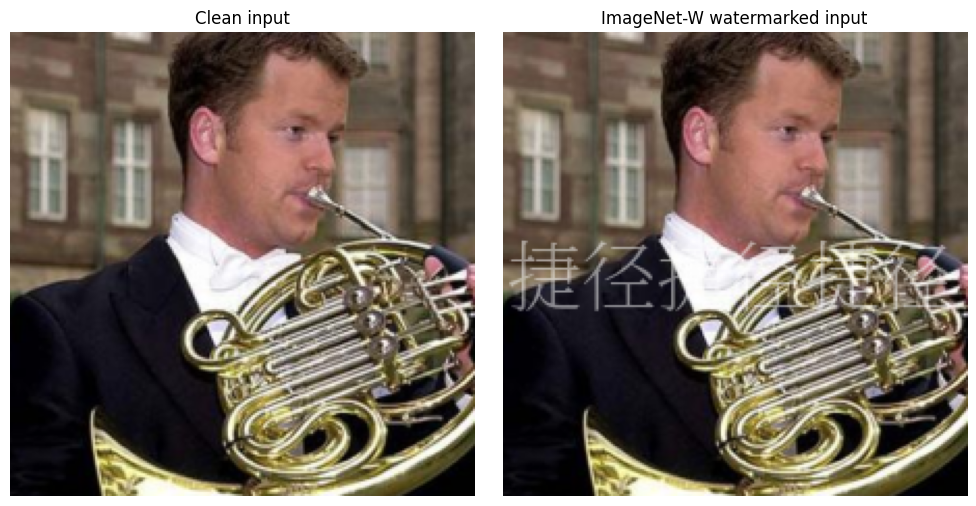

Initial explanation target: 'carton' (index 478)


In [3]:
model, class_names = load_pretrained_resnet18(device)
image_path, clean_display_image, watermarked_display_image = load_watermark_example(
    WORKSHOP_DATA_ROOT,
    device,
)
display_image = watermarked_display_image
# Every method below initially answers the same target-specific question.
CARTON_TARGET_NAME = "carton"
carton_target_index = resolve_imagenet_class_index(CARTON_TARGET_NAME)
# The short alias is used by the method cells in sections 2 and 3.
target_index = carton_target_index
assert class_names[carton_target_index] == CARTON_TARGET_NAME

with torch.no_grad():
    clean_logits = model(normalize_imagenet(clean_display_image))[0]
    watermarked_logits = model(normalize_imagenet(watermarked_display_image))[0]

for label, logits in [("clean", clean_logits), ("watermarked", watermarked_logits)]:
    probabilities = logits.softmax(dim=0)
    top_index = int(logits.argmax())
    print(
        f"{label:11s} prediction={class_names[top_index]:12s} "
        f"p={probabilities[top_index]:6.2%}  "
        f"carton logit={logits[carton_target_index]:+7.3f}"
    )

show_image_grid(
    [clean_display_image, watermarked_display_image],
    ["Clean input", "ImageNet-W watermarked input"],
)
print(
    f"Initial explanation target: {CARTON_TARGET_NAME!r} "
    f"(index {carton_target_index})"
)

---
## 2. Input Gradient, Gradient × Input, and SmoothGrad

For target logit $s_c(x)$, Input Gradient asks how an infinitesimal pixel change
would change that score:

$$G_i^{(c)}(x)=\frac{\partial s_c(x)}{\partial x_i}.$$

`input_gradient` returns one value per RGB input component with shape
`[1, 3, 224, 224]`. We reduce it in two different ways:

- **Input Gradient magnitude:** take the largest absolute RGB derivative at
  each pixel. This is unsigned sensitivity.
- **Gradient × Input:** multiply each derivative by its input value and sum RGB.
  This is a signed local first-order term with an implicit zero reference.

SmoothGrad evaluates gradients on noisy copies and averages them:

$$\bar G(x)=\frac{1}{n}\sum_{k=1}^{n}
\nabla_xs_c\!\left(\operatorname{clip}(x+\epsilon^{(k)})\right).$$

We expose both teaching choices: `SMOOTHGRAD_SAMPLES` controls the Monte Carlo
sample count, while `SMOOTHGRAD_NOISE_STD` controls perturbation strength in
the `[0,1]` pixel space. Twelve samples are fast, but not a stability study.


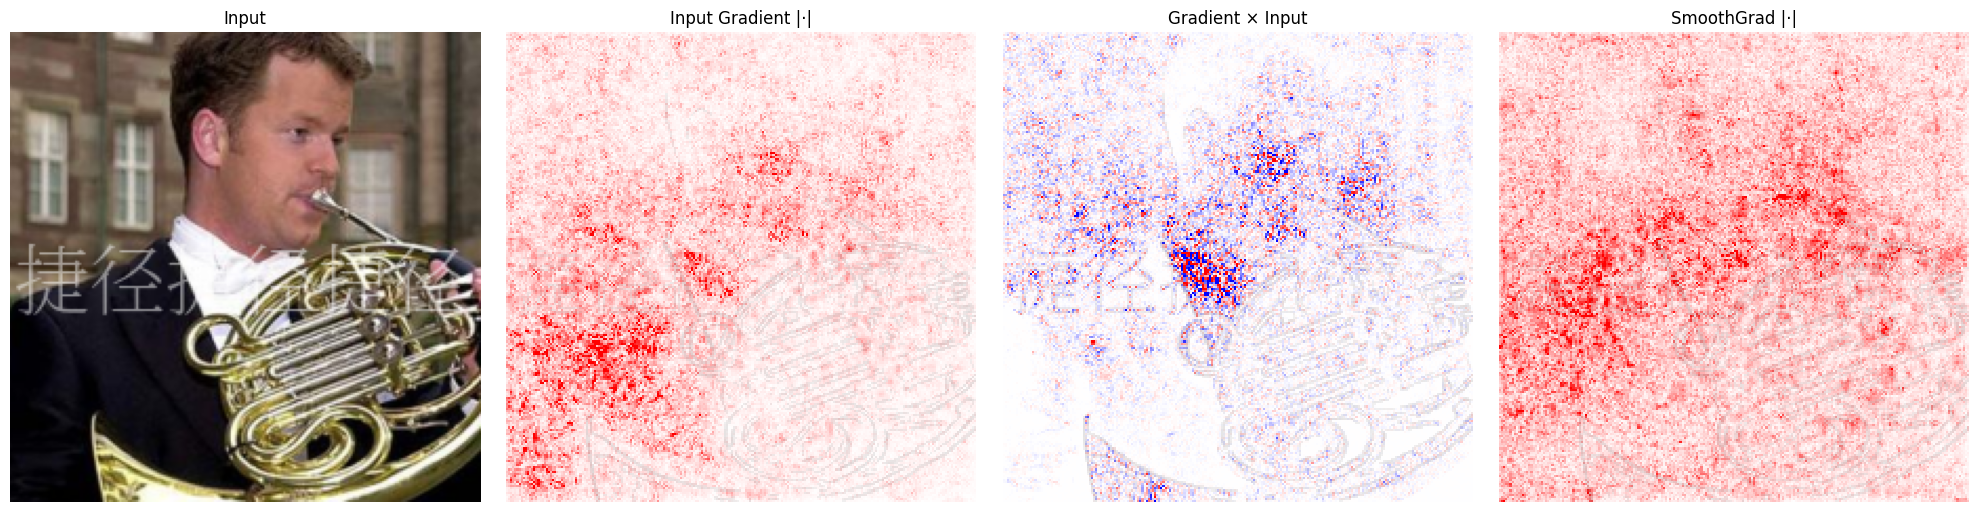

Target: 'carton'; score=4.016
Three gradient methods: 0.25s


In [4]:
gradient_start = time.perf_counter()

# One derivative per input component: [batch=1, RGB=3, height, width].
pixel_gradient, target_score = input_gradient(
    model,
    display_image,
    target_index,
)

# These reductions turn the three RGB derivatives into one 2D heatmap.
gradient_magnitude_map = gradient_magnitude(pixel_gradient)
gradient_x_input_map = gradient_times_input(display_image, pixel_gradient)

# Sample count affects estimator variance; noise controls the neighborhood size.
SMOOTHGRAD_SAMPLES = 12
SMOOTHGRAD_NOISE_STD = 0.10
average_noisy_gradient = smoothgrad(
    model,
    display_image,
    target_index,
    samples=SMOOTHGRAD_SAMPLES,
    noise=SMOOTHGRAD_NOISE_STD,
)
smoothgrad_magnitude_map = gradient_magnitude(average_noisy_gradient)

# q=99.5 uses the 99.5th percentile of |attribution| as the color limit.
plot_bwr_attributions(
    display_image,
    [gradient_magnitude_map, gradient_x_input_map, smoothgrad_magnitude_map],
    ["Input Gradient |·|", "Gradient × Input", "SmoothGrad |·|"],
    q=99.5,
)
print(f"Target: {class_names[target_index]!r}; score={target_score:.3f}")
print(f"Three gradient methods: {time.perf_counter() - gradient_start:.2f}s")

**Compare the nouns, not only the pictures:** sensitivity, local first-order term, and smoothed sensitivity are different mathematical objects. Smoothness is not evidence of faithfulness.

---
## 3. CAM and Grad-CAM

Both methods explain a target using hidden feature maps
$A\in\mathbb{R}^{K\times H\times W}$, but they obtain channel importance
differently.

**CAM** uses the target class's learned classifier weights:

$$M_{\mathrm{CAM}}^c(i,j)=\sum_kw_k^cA_{ij}^k,
\qquad s_c=\operatorname{mean}_{i,j}(M_{\mathrm{CAM}}^c)+b_c.$$

This formula requires a global-average-pooling → linear-classifier head, which
ResNet-18 has. The CAM map remains signed.

**Grad-CAM** works with more architectures. It spatially averages target
gradients to obtain one weight per channel, then keeps positive evidence:

$$\alpha_k^c=\frac{1}{HW}\sum_{i,j}
\frac{\partial s_c}{\partial A_{ij}^k},\qquad
L_{\mathrm{Grad-CAM}}^c=\operatorname{ReLU}\!\left(\sum_k\alpha_k^cA^k\right).$$

The selected layer defines the explanation's spatial resolution and semantic
level. Here `model.layer4` returns the final `7×7` ResNet feature maps.


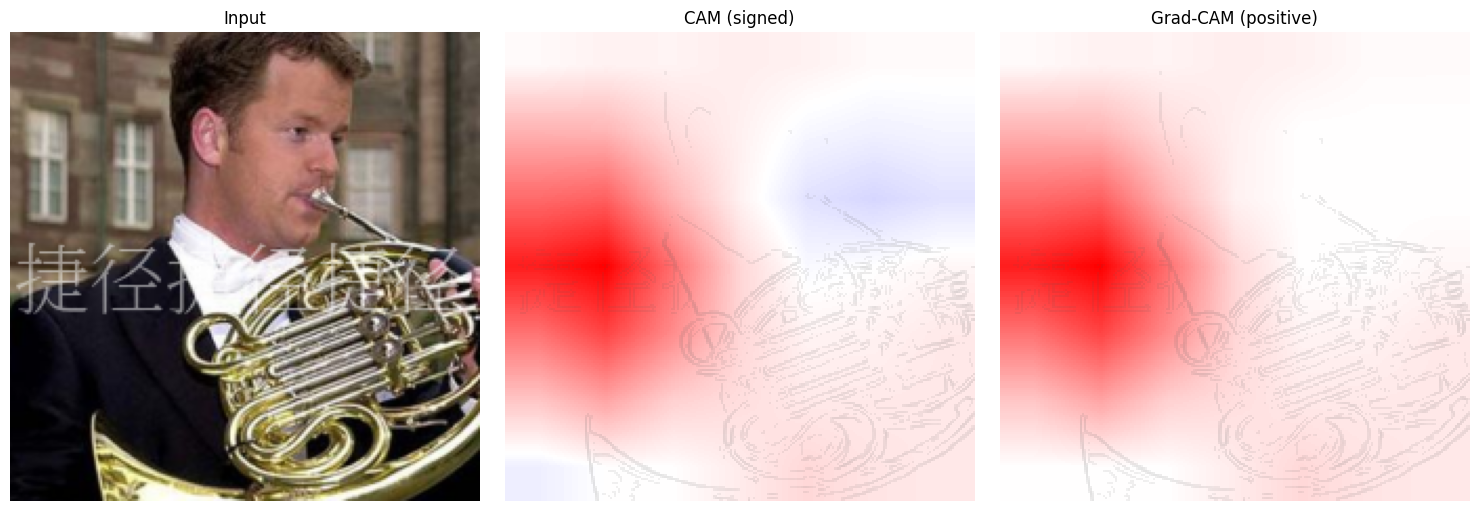

Model logit              : 4.015978
mean(CAM) + bias         : 4.015978
CAM/Grad-CAM correlation : 1.00000000
CAM and Grad-CAM          : 0.00 seconds


In [5]:
cam_layer = model.layer4
# ResNet layer4 produces the final, semantically strongest 7×7 feature maps.
cam_start = time.perf_counter()

signed_cam, cam_logit, reconstructed_logit = cam(
    model,
    display_image,
    target_index,
    cam_layer,
)
positive_gradcam, _ = gradcam(
    model,
    display_image,
    target_index,
    cam_layer,
)
cam_seconds = time.perf_counter() - cam_start

# CAM is signed; this Grad-CAM implementation applies ReLU and is non-negative.
plot_bwr_attributions(
    display_image,
    [signed_cam, positive_gradcam],
    ["CAM (signed)", "Grad-CAM (positive)"],
    q=100,
)

# Normalize only for comparing spatial patterns, not for conservation.
positive_cam = signed_cam.relu()
normalized_cam = positive_cam / positive_cam.amax().clamp_min(1e-12)
normalized_gradcam = positive_gradcam / positive_gradcam.amax().clamp_min(1e-12)
map_correlation = torch.corrcoef(
    torch.stack([normalized_cam.flatten(), normalized_gradcam.flatten()])
)[0, 1]

print(f"Model logit              : {cam_logit:.6f}")
print(f"mean(CAM) + bias         : {reconstructed_logit:.6f}")
print(f"CAM/Grad-CAM correlation : {map_correlation.item():.8f}")
print(f"CAM and Grad-CAM          : {cam_seconds:.2f} seconds")

# These identities follow from ResNet-18's GAP → linear classifier head.
assert np.isclose(cam_logit, reconstructed_logit, atol=1e-5)
assert map_correlation > 0.999

At ResNet-18's final feature maps,

$$
\frac{\partial s_c}{\partial A_{ij}^k}=\frac{w_k^c}{HW}.
$$

Positive CAM and Grad-CAM are therefore identical up to scale here. The numerical check is an architectural invariant, not a claim that both methods are generally equivalent.

---
## 4. Target specificity: shortcut versus intended object

The same watermarked pixels can support or oppose different outputs. We compare
the shortcut-associated `carton` logit with the intended `French horn` logit and
print both scores before interpreting either map.


carton                   logit=  4.016  probability= 0.000%
French horn              logit= 27.628  probability=99.865%


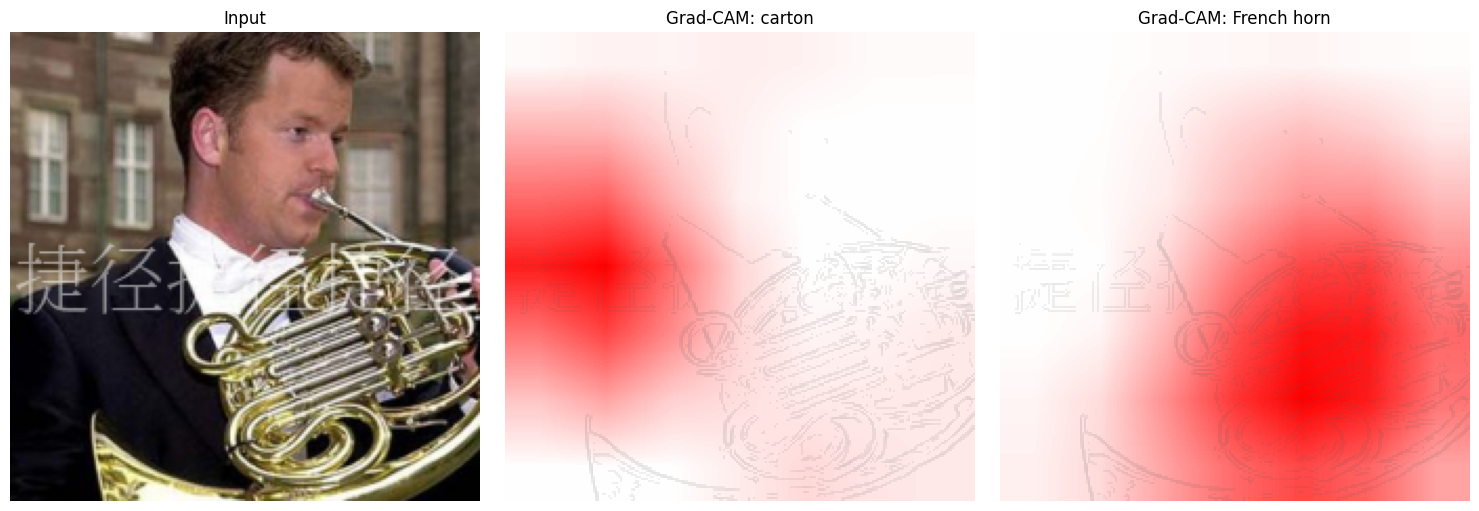

(<Figure size 1500x500 with 3 Axes>,
 array([<Axes: title={'center': 'Input'}>,
        <Axes: title={'center': 'Grad-CAM: carton'}>,
        <Axes: title={'center': 'Grad-CAM: French horn'}>], dtype=object),
 [0.4835532605648041, 1.8304243087768555])

In [6]:
alternative_name = "French horn"
alternative_index = resolve_imagenet_class_index(alternative_name)

# Keep the image and layer fixed; change only the explained output score.
carton_gradcam, carton_logit = gradcam(
    model,
    display_image,
    carton_target_index,
    model.layer4,
)
french_horn_gradcam, french_horn_logit = gradcam(
    model,
    display_image,
    alternative_index,
    model.layer4,
)

# Probabilities provide context; each heatmap still explains a logit.
with torch.no_grad():
    probabilities = model(normalize_imagenet(display_image)).softmax(dim=1)[0]

print(
    f"{CARTON_TARGET_NAME:24s} "
    f"logit={carton_logit:7.3f}  "
    f"probability={probabilities[carton_target_index].item():7.3%}"
)
print(
    f"{alternative_name:24s} "
    f"logit={french_horn_logit:7.3f}  "
    f"probability={probabilities[alternative_index].item():7.3%}"
)
plot_bwr_attributions(
    display_image,
    [carton_gradcam, french_horn_gradcam],
    [f"Grad-CAM: {CARTON_TARGET_NAME}", f"Grad-CAM: {alternative_name}"],
    q=100,
)

The two maps answer different target-conditional
questions. The direct clean/watermarked score comparison establishes that this
specific watermark changes the behavior; neither heatmap alone establishes a
general causal mechanism.


---
## 5. Layer choice changes resolution and meaning

Grad-CAM describes the selected layer, not the whole network in an
architecture-independent way. In ResNet-18:

- `layer2` is earlier, has more spatial cells, and responds to lower-level patterns;
- `layer4` is later, has fewer spatial cells, and represents more abstract patterns.

Both maps are enlarged for display. Upsampling a coarse `7×7` map does not
recover spatial detail that the layer no longer contains.


layer2 native map: (28, 28)
layer4 native map: (7, 7)


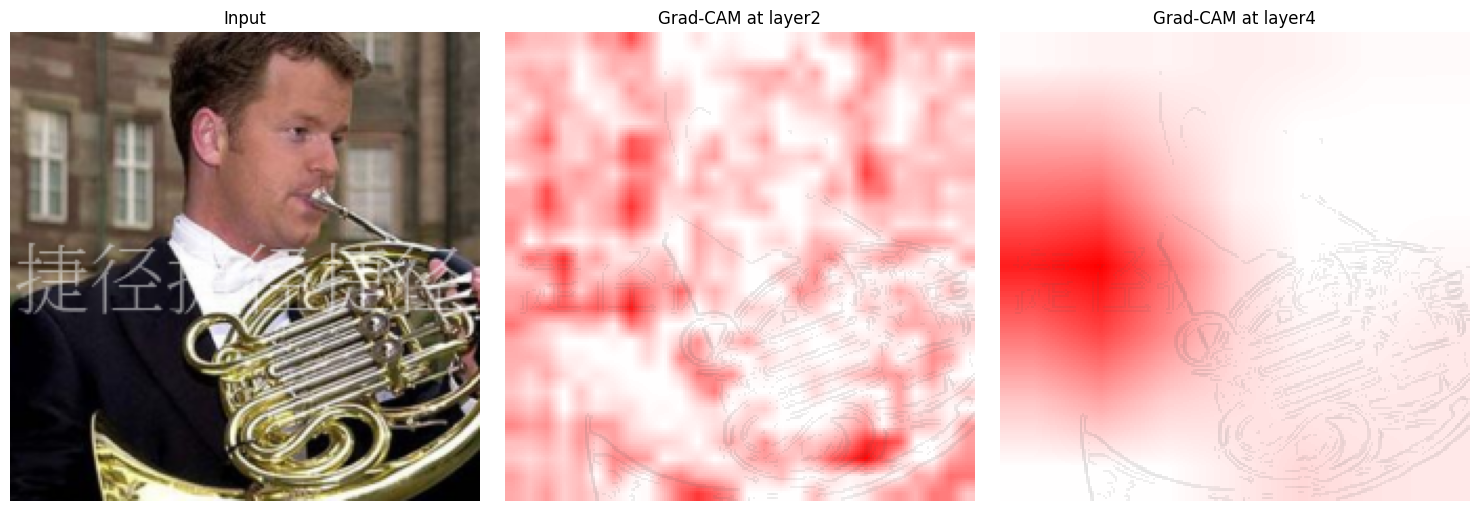

(<Figure size 1500x500 with 3 Axes>,
 array([<Axes: title={'center': 'Input'}>,
        <Axes: title={'center': 'Grad-CAM at layer2'}>,
        <Axes: title={'center': 'Grad-CAM at layer4'}>], dtype=object),
 [0.03378422558307648, 0.4835532605648041])

In [7]:
# Change only the inspected layer; image and target remain fixed.
layer2_gradcam, _ = gradcam(
    model,
    display_image,
    carton_target_index,
    model.layer2,
)
layer4_gradcam, _ = gradcam(
    model,
    display_image,
    carton_target_index,
    model.layer4,
)

print(f"layer2 native map: {tuple(layer2_gradcam.shape)}")
print(f"layer4 native map: {tuple(layer4_gradcam.shape)}")
plot_bwr_attributions(
    display_image,
    [layer2_gradcam, layer4_gradcam],
    ["Grad-CAM at layer2", "Grad-CAM at layer4"],
    q=100,
)

---
## 6. Optional VGG-16 extension

Standard VGG-16 ends in fully connected layers rather than a global-average-
pooling head, so the simple CAM equation is not valid. Grad-CAM still works
because it obtains channel weights from gradients.

We keep the explanation target fixed to `carton` for comparison with ResNet-18.
The cell is disabled because VGG-16 weights are large and it is outside the
fast workshop path.


In [8]:
# Enable only when VGG-16 weights are already cached or time permits.
RUN_VGG_EXAMPLE = False

if RUN_VGG_EXAMPLE:
    vgg_model, vgg_class_names = load_pretrained_vgg16(device)
    vgg_target_index = carton_target_index

    # features[28] is VGG-16's final convolution, before ReLU and max-pooling.
    vgg_gradcam, vgg_target_logit = gradcam(
        vgg_model,
        display_image,
        vgg_target_index,
        vgg_model.features[28],
    )
    plot_bwr_attributions(
        display_image,
        [vgg_gradcam],
        [f"VGG-16 Grad-CAM: {vgg_class_names[vgg_target_index]}"],
        q=100,
    )
    print(f"VGG-16 target logit: {vgg_target_logit:+.3f}")

    # Release the large optional model before continuing in a small runtime.
    del vgg_model
    if device.type == "cuda":
        torch.cuda.empty_cache()
else:
    print("Skipped. Set RUN_VGG_EXAMPLE=True to run VGG-16.")

Skipped. Set RUN_VGG_EXAMPLE=True to run VGG-16.


---
## Take-home checklist

| Method | Main quantity | Main caution |
|---|---|---|
| Input Gradient | local sensitivity | saturation and noise |
| Gradient × Input | local first-order term | implicit zero reference |
| SmoothGrad | average nearby sensitivity | smoothness is not faithfulness |
| CAM | classifier-weighted feature maps | requires GAP → linear head |
| Grad-CAM | positive gradient-weighted feature maps | coarse and layer-dependent |

Report the model/checkpoint, target logit, preprocessing, sign and channel reduction, SmoothGrad noise/sample settings, CAM/Grad-CAM target layer, ReLU, upsampling, and normalization.

### References

- Simonyan, Vedaldi & Zisserman (2013), [Deep Inside Convolutional Networks](https://arxiv.org/abs/1312.6034)
- Smilkov et al. (2017), [SmoothGrad](https://arxiv.org/abs/1706.03825)
- Zhou et al. (2016), [CAM](https://openaccess.thecvf.com/content_cvpr_2016/html/Zhou_Learning_Deep_Features_CVPR_2016_paper.html)
- Selvaraju et al. (2017), [Grad-CAM](https://openaccess.thecvf.com/content_iccv_2017/html/Selvaraju_Grad-CAM_Visual_Explanations_ICCV_2017_paper.html)